#  Notebook 1 — Data Loading, EDA & Preprocessing
## IU Chest X-Ray Dataset (Indiana University / Open-i)

**Dataset:** `raddar/chest-xrays-indiana-university` on Kaggle  



In [14]:
!pip install -q kagglehub torch torchvision albumentations transformers scikit-learn pandas opencv-python tqdm nltk matplotlib seaborn
print('Packages installed')

Packages installed



[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
# ── 0. Imports & global config ───────────────────────────────────────────────
import os, re, logging, warnings
import kagglehub
import numpy as np
import pandas as pd
import cv2
from pathlib import Path
from tqdm import tqdm
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import nltk
nltk.download('punkt',    quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = min(4, max(1, os.cpu_count() // 2))   # safe for VS Code / Jupyter

print(f"Imports OK  |  Device: {DEVICE}  |  num_workers: {NUM_WORKERS}")


Imports OK  |  Device: cuda  |  num_workers: 4


## Step 1 — Download the Dataset via KaggleHub

In [16]:
from pathlib import Path
import kagglehub
import shutil

# Project dataset location
project_data_path = Path("D:/Projects/ScratchRadiology/data/indiana_dataset")
project_data_path.mkdir(parents=True, exist_ok=True)

# Download only if not already present
if not project_data_path.exists() or not any(project_data_path.iterdir()):
    cache_path = kagglehub.dataset_download(
        "raddar/chest-xrays-indiana-university",
        output_dir=str(project_data_path)  #  downloads directly here
    )
    print(f"Dataset downloaded to: {cache_path}")
else:
    print("Dataset already exists")

# Define paths — always runs
IMG_DIR     = project_data_path / "images/images_normalized"
PROJ_CSV    = project_data_path / "indiana_projections.csv"
REPORTS_CSV = project_data_path / "indiana_reports.csv"

print(IMG_DIR.exists())
print(PROJ_CSV.exists())
print(REPORTS_CSV.exists())

Dataset already exists
True
True
True


## Step 2 — Load & Inspect CSVs

In [17]:
df_proj    = pd.read_csv(PROJ_CSV)
df_reports = pd.read_csv(REPORTS_CSV)

print("=== indiana_projections.csv ===")
print(df_proj.head(6).to_string())
print(f"\nShape: {df_proj.shape}  |  Columns: {df_proj.columns.tolist()}")

print("\n=== indiana_reports.csv ===")
print(df_reports.head(3).to_string())
print(f"\nShape: {df_reports.shape}  |  Columns: {df_reports.columns.tolist()}")

print("\nProjection value counts:")
print(df_proj['projection'].value_counts())

print("\nNull values in reports CSV:")
print(df_reports.isnull().sum())


=== indiana_projections.csv ===
   uid                filename projection
0    1  1_IM-0001-4001.dcm.png    Frontal
1    1  1_IM-0001-3001.dcm.png    Lateral
2    2  2_IM-0652-1001.dcm.png    Frontal
3    2  2_IM-0652-2001.dcm.png    Lateral
4    3  3_IM-1384-1001.dcm.png    Frontal
5    3  3_IM-1384-2001.dcm.png    Lateral

Shape: (7466, 3)  |  Columns: ['uid', 'filename', 'projection']

=== indiana_reports.csv ===
   uid                                               MeSH                       Problems                                image                                                                                                                                  indication comparison                                                                                                                                                                                                            findings                                                                                            

  IU CHEST X-RAY DATASET — COMPLETE OVERVIEW

  SOURCE      : Kaggle — raddar/chest-xrays-indiana-university
  ORIGIN      : Indiana University / Open-i (NIH)

   IMAGES
     Total images    : 7,466
     Frontal (PA/AP) : 3,818  (51.1%)
     Lateral         : 3,648  (48.9%)
     Format          : PNG, normalized, 8-bit grayscale
     Resolution      : Variable → resized to 224×224 for training

   REPORTS
     Total reports   : 3,851
     Unique patients : 3,851
     Avg images/report: 1.9

  REPORT COLUMNS
     uid                 : 3,851 non-null  (100.0%)
     MeSH                : 3,851 non-null  (100.0%)
     Problems            : 3,851 non-null  (100.0%)
     image               : 3,851 non-null  (100.0%)
     indication          : 3,765 non-null  (97.8%)
     comparison          : 2,685 non-null  (69.7%)
     findings            : 3,337 non-null  (86.7%)
     impression          : 3,820 non-null  (99.2%)

   TEXT STATISTICS
     Findings   — avg words : 31.5  (min=7, max=169)
  

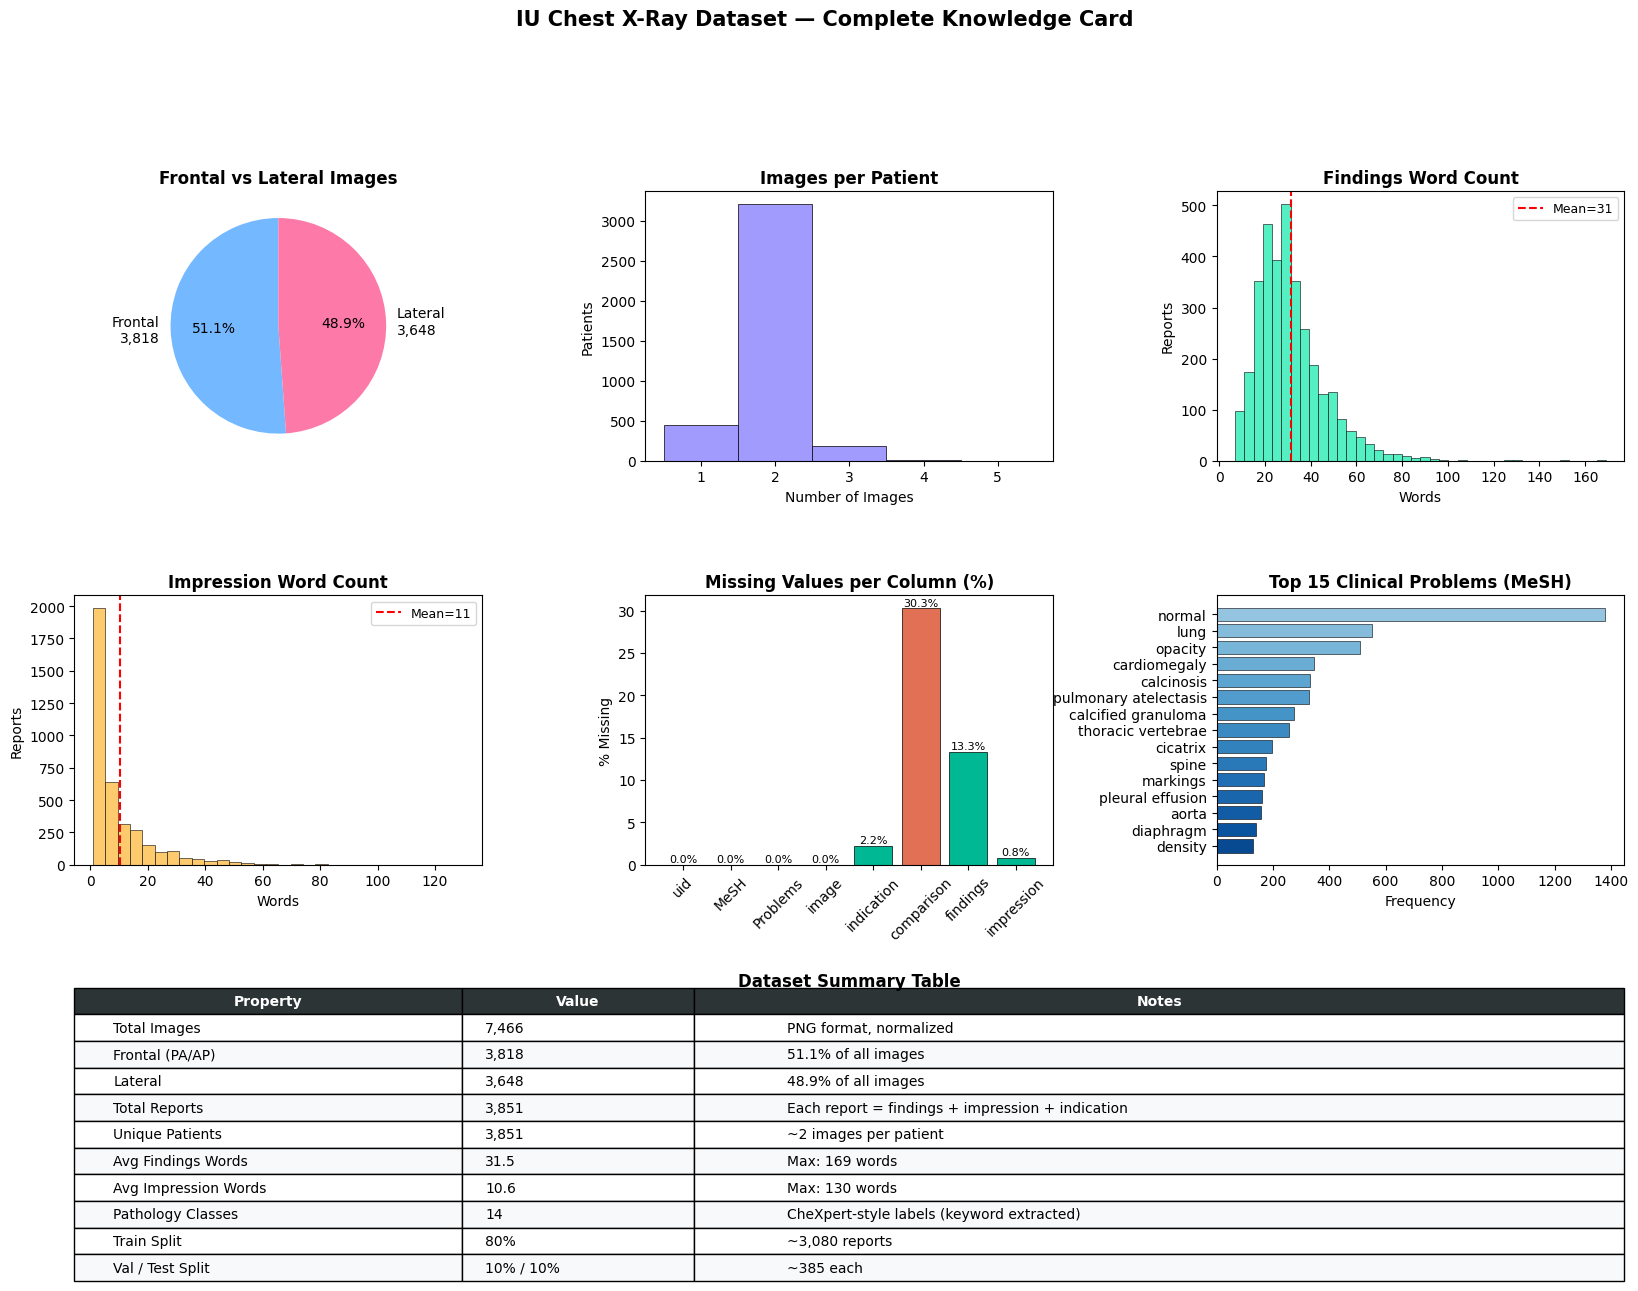


Saved → nb1_outputs/dataset_knowledge_card.png


In [18]:
# ============================================================
# DATASET KNOWLEDGE — Complete Overview
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

print("=" * 60)
print("  IU CHEST X-RAY DATASET — COMPLETE OVERVIEW")
print("=" * 60)

# ── Basic counts ──────────────────────────────────────────────
total_images   = len(df_proj)
frontal_count  = (df_proj['projection'].str.lower() == 'frontal').sum()
lateral_count  = (df_proj['projection'].str.lower() == 'lateral').sum()
total_reports  = len(df_reports)
total_patients = df_proj['uid'].nunique()

print(f"\n  SOURCE      : Kaggle — raddar/chest-xrays-indiana-university")
print(f"  ORIGIN      : Indiana University / Open-i (NIH)")
print(f"\n   IMAGES")
print(f"     Total images    : {total_images:,}")
print(f"     Frontal (PA/AP) : {frontal_count:,}  ({100*frontal_count/total_images:.1f}%)")
print(f"     Lateral         : {lateral_count:,}  ({100*lateral_count/total_images:.1f}%)")
print(f"     Format          : PNG, normalized, 8-bit grayscale")
print(f"     Resolution      : Variable → resized to 224×224 for training")
print(f"\n   REPORTS")
print(f"     Total reports   : {total_reports:,}")
print(f"     Unique patients : {total_patients:,}")
print(f"     Avg images/report: {total_images/total_reports:.1f}")
print(f"\n  REPORT COLUMNS")
for col in df_reports.columns:
    n_filled = df_reports[col].notna().sum()
    print(f"     {col:20s}: {n_filled:,} non-null  ({100*n_filled/len(df_reports):.1f}%)")

# ── Findings text statistics ──────────────────────────────────
wc_findings   = df_reports['findings'].dropna().apply(lambda x: len(str(x).split()))
wc_impression = df_reports['impression'].dropna().apply(lambda x: len(str(x).split()))

print(f"\n   TEXT STATISTICS")
print(f"     Findings   — avg words : {wc_findings.mean():.1f}  "
      f"(min={wc_findings.min()}, max={wc_findings.max()})")
print(f"     Impression — avg words : {wc_impression.mean():.1f}  "
      f"(min={wc_impression.min()}, max={wc_impression.max()})")
print(f"\n  🔬 PATHOLOGY LABELS (14 CheXpert-style, keyword extracted)")
print(f"     Generated in NB2 from findings + impression text")
print("=" * 60)

# ── Visual dashboard ──────────────────────────────────────────
fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.4)

# 1. Frontal vs Lateral pie
ax1 = fig.add_subplot(gs[0, 0])
ax1.pie([frontal_count, lateral_count],
        labels=[f'Frontal\n{frontal_count:,}', f'Lateral\n{lateral_count:,}'],
        colors=['#74b9ff','#fd79a8'],
        autopct='%1.1f%%', startangle=90,
        textprops={'fontsize':10})
ax1.set_title("Frontal vs Lateral Images", fontweight='bold')

# 2. Images per patient distribution
ax2 = fig.add_subplot(gs[0, 1])
imgs_per_patient = df_proj.groupby('uid').size()
ax2.hist(imgs_per_patient, bins=range(1, imgs_per_patient.max()+2),
         color='#a29bfe', edgecolor='black', lw=0.5, align='left')
ax2.set_title("Images per Patient", fontweight='bold')
ax2.set_xlabel("Number of Images"); ax2.set_ylabel("Patients")
for v in imgs_per_patient.value_counts().items():
    pass

# 3. Findings word count distribution
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(wc_findings, bins=40, color='#55efc4', edgecolor='black', lw=0.4)
ax3.axvline(wc_findings.mean(), color='red', linestyle='--',
            label=f'Mean={wc_findings.mean():.0f}')
ax3.set_title("Findings Word Count", fontweight='bold')
ax3.set_xlabel("Words"); ax3.set_ylabel("Reports"); ax3.legend(fontsize=9)

# 4. Impression word count
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(wc_impression, bins=30, color='#fdcb6e', edgecolor='black', lw=0.4)
ax4.axvline(wc_impression.mean(), color='red', linestyle='--',
            label=f'Mean={wc_impression.mean():.0f}')
ax4.set_title("Impression Word Count", fontweight='bold')
ax4.set_xlabel("Words"); ax4.set_ylabel("Reports"); ax4.legend(fontsize=9)

# 5. Missing values
ax5 = fig.add_subplot(gs[1, 1])
null_pct = df_reports.isnull().mean() * 100
colors_null = ['#e17055' if v > 20 else '#00b894' for v in null_pct.values]
bars = ax5.bar(null_pct.index, null_pct.values,
               color=colors_null, edgecolor='black', lw=0.5)
ax5.set_title("Missing Values per Column (%)", fontweight='bold')
ax5.set_ylabel("% Missing"); ax5.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, null_pct.values):
    ax5.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'{val:.1f}%', ha='center', fontsize=8)

# 6. Top 15 problems
ax6 = fig.add_subplot(gs[1, 2])
from collections import Counter
all_problems = []
for p in df_reports['Problems'].dropna():
    all_problems.extend([x.strip().lower() for x in str(p).split(';') if x.strip()])
top_problems = Counter(all_problems).most_common(15)
if top_problems:
    labels_p, counts_p = zip(*top_problems)
    colors_p = plt.cm.Blues(np.linspace(0.4, 0.9, len(labels_p)))
    ax6.barh(labels_p, counts_p, color=colors_p, edgecolor='black', lw=0.4)
    ax6.set_title("Top 15 Clinical Problems (MeSH)", fontweight='bold')
    ax6.set_xlabel("Frequency"); ax6.invert_yaxis()

# 7. Summary table
ax7 = fig.add_subplot(gs[2, :])
ax7.axis('off')
table_data = [
    ["Total Images",       f"{total_images:,}",    "PNG format, normalized"],
    ["Frontal (PA/AP)",    f"{frontal_count:,}",    f"{100*frontal_count/total_images:.1f}% of all images"],
    ["Lateral",            f"{lateral_count:,}",    f"{100*lateral_count/total_images:.1f}% of all images"],
    ["Total Reports",      f"{total_reports:,}",    "Each report = findings + impression + indication"],
    ["Unique Patients",    f"{total_patients:,}",   "~2 images per patient"],
    ["Avg Findings Words", f"{wc_findings.mean():.1f}", f"Max: {wc_findings.max()} words"],
    ["Avg Impression Words",f"{wc_impression.mean():.1f}",f"Max: {wc_impression.max()} words"],
    ["Pathology Classes",  "14",                    "CheXpert-style labels (keyword extracted)"],
    ["Train Split",        "80%",                   f"~{int(total_reports*0.8):,} reports"],
    ["Val / Test Split",   "10% / 10%",             f"~{int(total_reports*0.1):,} each"],
]
tbl = ax7.table(
    cellText=table_data,
    colLabels=["Property", "Value", "Notes"],
    cellLoc='left', loc='center',
    colWidths=[0.25, 0.15, 0.6]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.6)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2d3436')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#f8f9fa')
ax7.set_title("Dataset Summary Table", fontweight='bold', fontsize=12, pad=10)

plt.suptitle("IU Chest X-Ray Dataset — Complete Knowledge Card",
             fontsize=15, fontweight='bold', y=1.01)
os.makedirs("nb1_outputs", exist_ok=True)
plt.savefig("nb1_outputs/dataset_knowledge_card.png", dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print("\nSaved → nb1_outputs/dataset_knowledge_card.png")

## Step 3 — Merge & Build Master DataFrame

Each report (uid) may link to 1-4 images.  
Strategy:
- Keep **one Frontal** + **one Lateral** image per uid
- If only one projection exists → replicate it (standard practice for IU X-Ray)

In [19]:
def build_master_df(df_proj: pd.DataFrame, df_reports: pd.DataFrame,
                    img_dir: Path) -> pd.DataFrame:
    """
    Merge projections with reports, selecting one frontal + one lateral per uid.
    Returns master DataFrame with columns:
        uid, frontal_path, lateral_path, findings, impression,
        indication, comparison, mesh_tags, problems
    """
    records = []
    for uid, grp in df_proj.groupby('uid'):
        frontal = grp[grp['projection'].str.lower() == 'frontal']['filename'].values
        lateral = grp[grp['projection'].str.lower() == 'lateral']['filename'].values

        f_file = frontal[0] if len(frontal) > 0 else (lateral[0] if len(lateral) > 0 else None)
        l_file = lateral[0] if len(lateral) > 0 else f_file

        if f_file is None:
            continue

        f_path = img_dir / f_file
        l_path = img_dir / l_file

        if not f_path.exists():
            continue

        records.append({
            'uid': uid,
            'frontal_path': str(f_path),
            'lateral_path': str(l_path),
        })

    df_img    = pd.DataFrame(records)
    df_merged = df_img.merge(df_reports, on='uid', how='inner')

    rename_map = {
        'MeSH'    : 'mesh_tags',
        'Problems': 'problems',
    }
    df_merged.rename(columns={k: v for k, v in rename_map.items()
                               if k in df_merged.columns}, inplace=True)

    df_merged = df_merged[
        df_merged['findings'].notna() &
        (df_merged['findings'].str.strip().str.len() > 0)
    ].reset_index(drop=True)

    logging.info(f"Master DF: {len(df_merged)} valid report-image pairs")
    return df_merged


df = build_master_df(df_proj, df_reports, IMG_DIR)
print(f"Master DataFrame shape: {df.shape}")
print(df[['uid', 'frontal_path', 'findings', 'impression']].head(3).to_string())


INFO: Master DF: 3337 valid report-image pairs


Master DataFrame shape: (3337, 10)
   uid                                                                                       frontal_path                                                                                                                                                                                                                                                                                                                                                                                                                                           findings                                                                                                                                                                                                                                                                                                                             impression
0    1  D:\Projects\ScratchRadiology\data\indiana_dataset\images\images_normalized\1_IM-0001-4001

## Step 4 — Exploratory Data Analysis

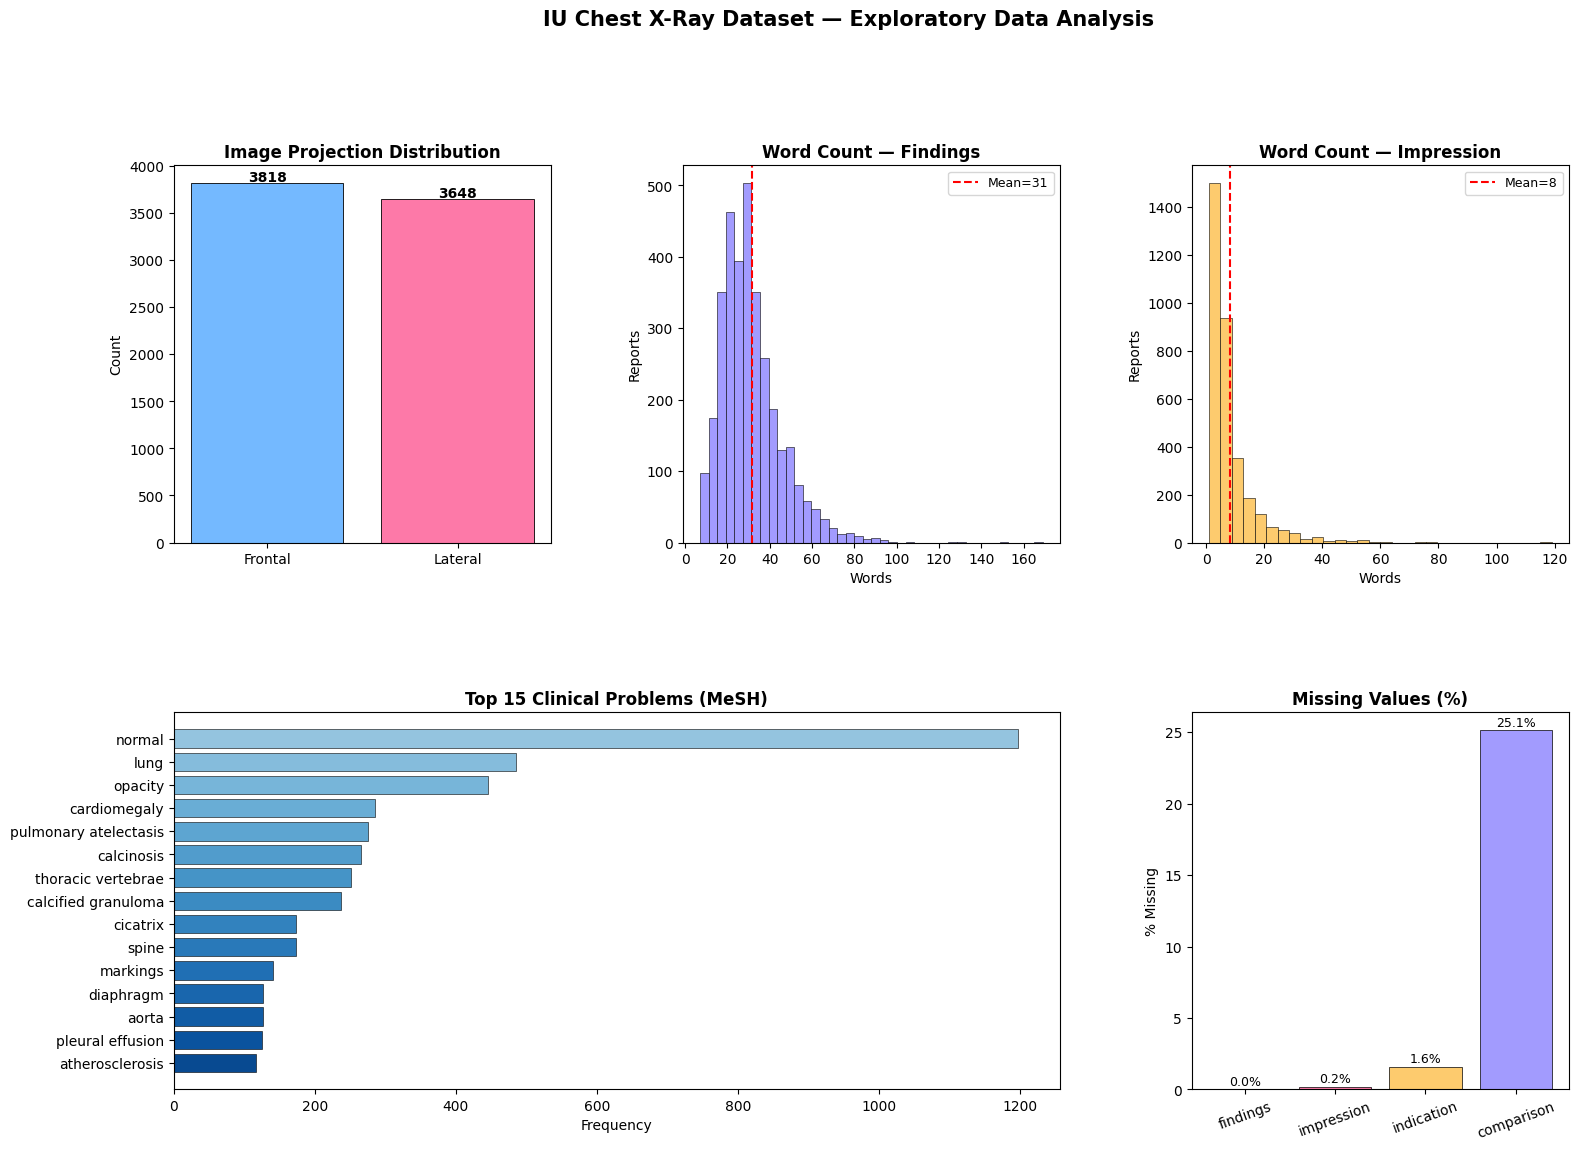


Dataset summary:
  Total reports         : 3337
  Avg findings words    : 31.5  (max=169)
  Avg impression words  : 8.1  (max=119)
  Unique UIDs           : 3337


In [20]:
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1. Projection distribution
ax1 = fig.add_subplot(gs[0, 0])
proj_counts = df_proj['projection'].value_counts()
ax1.bar(proj_counts.index, proj_counts.values,
        color=['#74b9ff','#fd79a8'], edgecolor='black', linewidth=0.6)
ax1.set_title("Image Projection Distribution", fontweight='bold')
ax1.set_ylabel("Count")
for i, v in enumerate(proj_counts.values):
    ax1.text(i, v + 20, str(v), ha='center', fontweight='bold')

# 2. Word count — Findings
ax2 = fig.add_subplot(gs[0, 1])
wc_findings = df['findings'].dropna().apply(lambda x: len(str(x).split()))
ax2.hist(wc_findings, bins=40, color='#a29bfe', edgecolor='black', linewidth=0.4)
ax2.axvline(wc_findings.mean(), color='red', linestyle='--',
            label=f'Mean={wc_findings.mean():.0f}')
ax2.set_title("Word Count — Findings", fontweight='bold')
ax2.set_xlabel("Words"); ax2.set_ylabel("Reports"); ax2.legend(fontsize=9)

# 3. Word count — Impression
ax3 = fig.add_subplot(gs[0, 2])
wc_imp = df['impression'].dropna().apply(lambda x: len(str(x).split()))
ax3.hist(wc_imp, bins=30, color='#fdcb6e', edgecolor='black', linewidth=0.4)
ax3.axvline(wc_imp.mean(), color='red', linestyle='--',
            label=f'Mean={wc_imp.mean():.0f}')
ax3.set_title("Word Count — Impression", fontweight='bold')
ax3.set_xlabel("Words"); ax3.set_ylabel("Reports"); ax3.legend(fontsize=9)

# 4. Top clinical problems
ax4 = fig.add_subplot(gs[1, 0:2])
all_problems = []
for p in df['problems'].dropna():
    all_problems.extend([x.strip().lower() for x in str(p).split(';') if x.strip()])
top_problems = Counter(all_problems).most_common(15)
if top_problems:
    labels_p, counts_p = zip(*top_problems)
    colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(labels_p)))
    ax4.barh(labels_p, counts_p, color=colors, edgecolor='black', linewidth=0.4)
    ax4.set_title("Top 15 Clinical Problems (MeSH)", fontweight='bold')
    ax4.set_xlabel("Frequency"); ax4.invert_yaxis()

# 5. Missing values
ax5 = fig.add_subplot(gs[1, 2])
null_pct = df[['findings','impression','indication','comparison']].isnull().mean() * 100
ax5.bar(null_pct.index, null_pct.values,
        color=['#55efc4','#fd79a8','#fdcb6e','#a29bfe'],
        edgecolor='black', linewidth=0.5)
ax5.set_title("Missing Values (%)", fontweight='bold')
ax5.set_ylabel("% Missing"); ax5.tick_params(axis='x', rotation=20)
for i, v in enumerate(null_pct.values):
    ax5.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

plt.suptitle("IU Chest X-Ray Dataset — Exploratory Data Analysis",
             fontsize=15, fontweight='bold', y=1.01)
plt.show()

print(f"\nDataset summary:")
print(f"  Total reports         : {len(df)}")
print(f"  Avg findings words    : {wc_findings.mean():.1f}  (max={wc_findings.max()})")
print(f"  Avg impression words  : {wc_imp.mean():.1f}  (max={wc_imp.max()})")
print(f"  Unique UIDs           : {df['uid'].nunique()}")


## Step 5 — Visualise Sample X-Ray Pairs

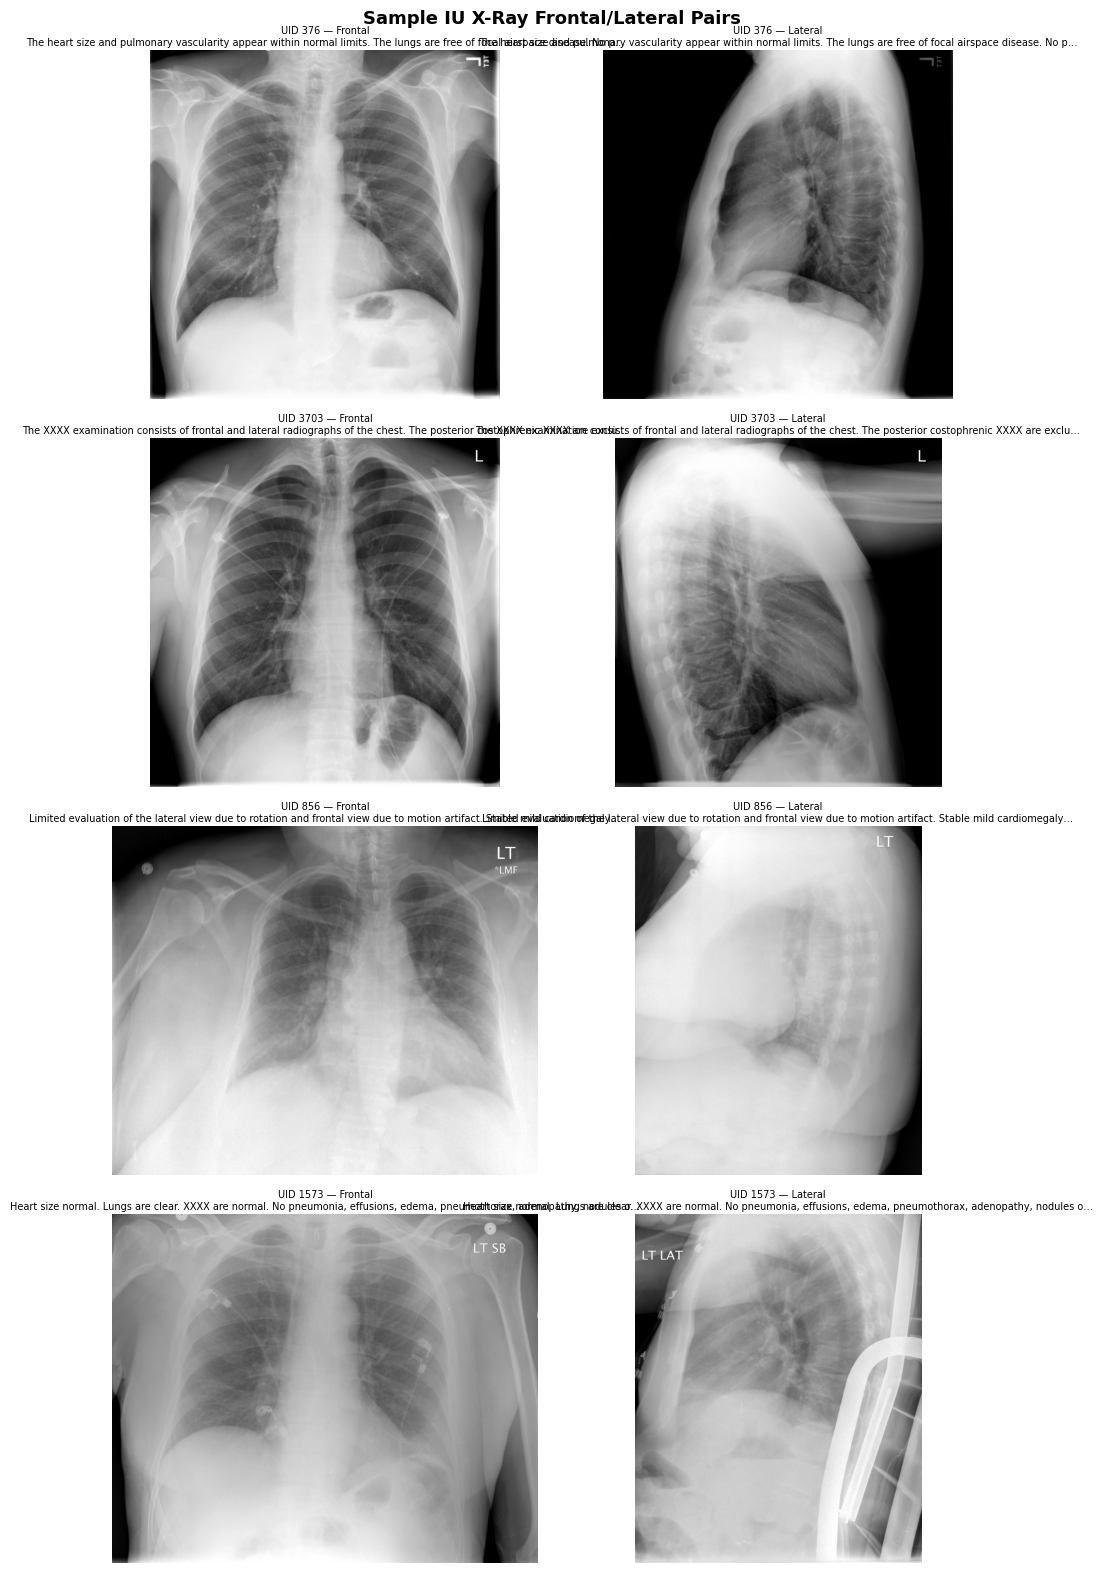

In [21]:
def show_xray_pairs(df: pd.DataFrame, n: int = 4, seed: int = 42):
    """Display frontal + lateral pairs with their findings text."""
    samples = df.sample(n, random_state=seed).reset_index(drop=True)
    fig, axes = plt.subplots(n, 2, figsize=(10, 4 * n))
    fig.suptitle("Sample IU X-Ray Frontal/Lateral Pairs", fontsize=13, fontweight='bold')

    for i, row in samples.iterrows():
        for j, (path_col, label) in enumerate([('frontal_path','Frontal'),
                                                ('lateral_path', 'Lateral')]):
            ax  = axes[i, j]
            img = cv2.imread(row[path_col], cv2.IMREAD_GRAYSCALE)
            if img is not None:
                ax.imshow(img, cmap='gray')
            else:
                ax.text(0.5, 0.5, 'Not found', ha='center', va='center')
            short_txt = str(row.get('findings', ''))[:120] + '…'
            ax.set_title(f"UID {row['uid']} — {label}\n{short_txt}",
                         fontsize=7, pad=3)
            ax.axis('off')

    plt.tight_layout()
    plt.show()

show_xray_pairs(df, n=4)


## Step 6 — Text Cleaning Pipeline

Text Preprocessing :-
This step cleans the radiology reports by removing unnecessary text, expanding medical abbreviations, normalizing numbers, and standardizing formatting. This improves text consistency and helps the model learn better patterns.

In [22]:
# ── Expanded medical abbreviation dictionary ──────────────────────────────────
MEDICAL_ABBREV = {
    # Original set
    'ap'   : 'anteroposterior',
    'pa'   : 'posteroanterior',
    'lat'  : 'lateral',
    'bilat': 'bilateral',
    'w/'   : 'with',
    'w/o'  : 'without',
    'r/o'  : 'rule out',
    'c/w'  : 'consistent with',
    'hx'   : 'history',
    'pt'   : 'patient',
    'dz'   : 'disease',
    'sob'  : 'shortness of breath',
    'chf'  : 'congestive heart failure',
    'pe'   : 'pulmonary embolism',
    'esp'  : 'especially',

    # New additions
    'yo'   : 'year old',
    'y/o'  : 'year old',
    'f/u'  : 'follow up',
    'h/o'  : 'history of',
    'p/w'  : 'presenting with',
    's/p'  : 'status post',
    'htn'  : 'hypertension',
    'dm'   : 'diabetes mellitus',
    'copd' : 'chronic obstructive pulmonary disease',
    'cad'  : 'coronary artery disease',
    'afib' : 'atrial fibrillation',
    'mi'   : 'myocardial infarction',
    'dvt'  : 'deep vein thrombosis',
    'uti'  : 'urinary tract infection',
    'lll'  : 'left lower lobe',
    'rll'  : 'right lower lobe',
    'lul'  : 'left upper lobe',
    'rul'  : 'right upper lobe',
    'bil'  : 'bilateral',
    'lg'   : 'large',
    'sm'   : 'small',
    'mod'  : 'moderate',
    'sev'  : 'severe',
    'neg'  : 'negative',
    'pos'  : 'positive',
    'abn'  : 'abnormal',
    'nml'  : 'normal',
    'nl'   : 'normal',
    'wnl'  : 'within normal limits',
    'nkda' : 'no known drug allergies',
    'meds' : 'medications',
    'hbp'  : 'high blood pressure',
    'cp'   : 'chest pain',
    'doe'  : 'dyspnea on exertion',
    'lbp'  : 'low back pain',
    'nausea/vomiting' : 'nausea and vomiting',
}

# Boilerplate phrases that add no diagnostic value
BOILERPLATE_PATTERNS = [
    r'pa and lateral views? of the chest( were)? (obtained|provided|submitted)',
    r'(frontal and lateral|ap and lateral|pa and lateral) chest( radiograph[s]?)?',
    r'(ap|pa|lateral) (view|projection|radiograph) of the chest',
    r'comparison is made (with|to) (the )?(prior|previous|old)',
    r'compared (with|to) (the )?(prior|previous|old)',
    r'no (prior|previous|old) (studies|films|radiographs|images) (are )?available for comparison',
    r'no comparison (studies|films|radiographs|images)?( available)?',
    r'history of\s*[:\-]?',
    r'indication[s]?\s*[:\-]?',
    r'reason for (exam|study|visit)\s*[:\-]?',
    r'clinical (history|indication)\s*[:\-]?',
    r'technically (adequate|limited|satisfactory) (examination|study|film)',
    r'this examination (was|is) (reviewed|interpreted)',
    r'the (radiologist|physician) (has )?reviewed',
]

STOP_WORDS = set(stopwords.words('english'))


def clean_report_text(text: str, remove_stopwords: bool = False) -> str:
    """
    Comprehensive cleaning pipeline for IU X-Ray reports.

    Step order is load-bearing — do not reorder:
      1. Age artifact fix   ← must see 'xxxx-year-old' intact
      2. xxxx removal       ← after age fix consumed the hyphenated form
      3. Leftover hyphens   ← after xxxx gone, clean orphaned dashes
      4. Numeric fixes      ← must run while hyphens/# /% still present
      5. Abbreviation expansion
      6. Boilerplate removal
      7. Allowed-chars strip + whitespace normalisation  ← last
      8. Optional stopword removal
    """
    if not isinstance(text, str) or not text.strip():
        return ""

    text = text.lower().strip()

    # ── 1. Age artifact fix BEFORE xxxx removal ───────────────────────────────
    # Pattern must match while 'xxxx' is still in the string
    text = re.sub(r'xxxx\s*-\s*years?\s*-?\s*old', 'year old', text)
    text = re.sub(r'xxxx\s*years?\s*old',           'year old', text)

    # ── 2. Remove remaining xxxx tokens ──────────────────────────────────────
    text = re.sub(r'\bxxxx\b', '', text)

    # ── 3. Leftover hyphen/dash artifacts after xxxx removal ──────────────────
    text = re.sub(r'^\s*[-–]\s*', '', text)      # leading dash  "- year old" → "year old"
    text = re.sub(r'\s+[-–]\s+',  ' ', text)     # isolated " - " inside text
    text = re.sub(r'[-–]{2,}',    ' ', text)      # double dashes "--"

    # ── 4. Numeric normalisation (must run BEFORE allowed-chars strip) ─────────
    text = re.sub(r'(\d)\s*-\s*(\d)', r'\1 to \2', text)   # 2-3   → 2 to 3
    text = re.sub(r'#\s*(\d)',         r'\1',        text)   # #2    → 2
    text = re.sub(r'\bx\s*(\d+)\b',   r'\1',        text)   # x2    → 2
    text = re.sub(r'(\d)\s*cm\b',     r'\1 cm',     text)   # 3cm   → 3 cm
    text = re.sub(r'(\d)\s*mm\b',     r'\1 mm',     text)   # 5mm   → 5 mm
    text = re.sub(r'(\d)\s*%',        r'\1 percent',text)   # 92%   → 92 percent

    # ── 5. Medical abbreviation expansion ────────────────────────────────────
    for abbr, full in MEDICAL_ABBREV.items():
        if re.match(r'^[a-z]+$', abbr):
            # alpha-only abbrs: whole-word match
            text = re.sub(r'\b' + re.escape(abbr) + r'\b', full, text)
        else:
            # symbol abbrs (w/, r/o, y/o …): literal replace
            text = text.replace(abbr, full)

    # ── 6. Boilerplate sentence removal ──────────────────────────────────────
    for pattern in BOILERPLATE_PATTERNS:
        text = re.sub(pattern, '', text, flags=re.IGNORECASE)

    # ── 7. Allowed-chars strip + whitespace normalisation (LAST) ─────────────
    # Hyphen intentionally excluded — all legitimate hyphens converted above
    text = re.sub(r'[^a-z0-9\s.,;:()/]', '', text)
    text = re.sub(r'\.{2,}',             '.', text)    # collapse "..."
    text = re.sub(r'\s+([.,;:])',        r'\1', text)  # space before punct
    text = re.sub(r'([.,;:])([^\s])',   r'\1 \2', text) # no space after punct
    text = re.sub(r'\s{2,}',             ' ', text)    # collapse spaces
    text = re.sub(r'^[.,;:\s]+',         '', text)     # leading punct artifacts

    # ── 8. Optional stopword removal ─────────────────────────────────────────
    if remove_stopwords:
        text = ' '.join(w for w in text.split() if w not in STOP_WORDS)

    return text.strip()


# ── Apply to dataframe ────────────────────────────────────────────────────────
df['findings_clean']   = df['findings'].apply(clean_report_text)
df['impression_clean'] = df['impression'].apply(clean_report_text)
df['clinical_history'] = (
    df.get('indication', pd.Series([''] * len(df)))
    .fillna('')
    .apply(clean_report_text)
)

sample = df.iloc[0]
print("=== BEFORE ===")
print(sample['findings'])
print("\n=== AFTER ===")
print(sample['findings_clean'])
print(f"\n Text cleaning applied to {len(df)} rows")


# ── Verification ──────────────────────────────────────────────────────────────
test_cases = [
    # (raw_input, substring_that_must_appear_in_output)

    # Age artifact
    ("xxxx-year-old female, chest pain",               "year old female"),
    ("xxxx year old male, sob",                         "year old male, shortness of breath"),
    ("xxxx-years-old patient",                          "year old patient"),
    ("- year old, cough",                               "year old"),

    # Numeric normalisation
    ("opacity measuring 2-3 cm",                        "2 to 3 cm"),
    ("lesion #2 in right lung",                         "lesion 2 in right lung"),
    ("bilateral infiltrates x2",                        "bilateral infiltrates 2"),
    ("nodule 8mm in diameter",                          "nodule 8 mm in diameter"),
    ("oxygen saturation 92%",                           "oxygen saturation 92 percent"),

    # Abbreviation expansion
    ("65 yo male, h/o chf, sob on exertion",           "year old"),
    ("s/p cabg, now w/ doe",                            "status post"),
    ("htn, dm, hx of mi",                               "hypertension"),
    ("bilateral lll consolidation",                     "bilateral left lower lobe"),
    ("findings wnl",                                    "within normal limits"),
    ("cp and sob for 2 days",                           "chest pain"),

    # Boilerplate removal
    ("pa and lateral views of the chest were obtained. cardiomegaly noted.",
                                                        "cardiomegaly noted"),
    ("no prior studies available for comparison. effusion present.",
                                                        "effusion present"),
    ("history of: chest pain and dyspnea",              "chest pain"),

    # Untouched normal text
    ("cardiomegaly with bilateral pleural effusion",    "cardiomegaly"),
    ("normal study no acute findings",                  "normal study"),
]

print("\n=== clean_report_text() — full verification ===\n")
passed = 0
for raw, expected in test_cases:
    result  = clean_report_text(raw)
    ok      = expected.lower() in result.lower()
    status  = "SUCCESS" if ok else "FAILED"
    passed += int(ok)
    print(f"  {status}  IN : {raw}")
    print(f"       OUT: {result}")
    if not ok:
        print(f"       EXP: '{expected}' not found  ← FAIL")
    print()

total = len(test_cases)
print(f"{'SUCCESS All' if passed == total else 'FAILED'} {passed}/{total} tests passed")

=== BEFORE ===
The cardiac silhouette and mediastinum size are within normal limits. There is no pulmonary edema. There is no focal consolidation. There are no XXXX of a pleural effusion. There is no evidence of pneumothorax.

=== AFTER ===
the cardiac silhouette and mediastinum size are within normal limits. there is no pulmonary edema. there is no focal consolidation. there are no of a pleural effusion. there is no evidence of pneumothorax.

 Text cleaning applied to 3337 rows

=== clean_report_text() — full verification ===

  SUCCESS  IN : xxxx-year-old female, chest pain
       OUT: year old female, chest pain

  SUCCESS  IN : xxxx year old male, sob
       OUT: year old male, shortness of breath

  SUCCESS  IN : xxxx-years-old patient
       OUT: year old patient

  SUCCESS  IN : - year old, cough
       OUT: year old, cough

  SUCCESS  IN : opacity measuring 2-3 cm
       OUT: opacity measuring 2 to 3 cm

  SUCCESS  IN : lesion #2 in right lung
       OUT: lesion 2 in right lung

## Step 7 — Image Augmentation Pipeline



This step applies mild image augmentations like flipping, rotation, brightness adjustment, and normalization to improve model robustness. Validation images are only resized and normalized. Augmentation samples are visualized to verify transformations.

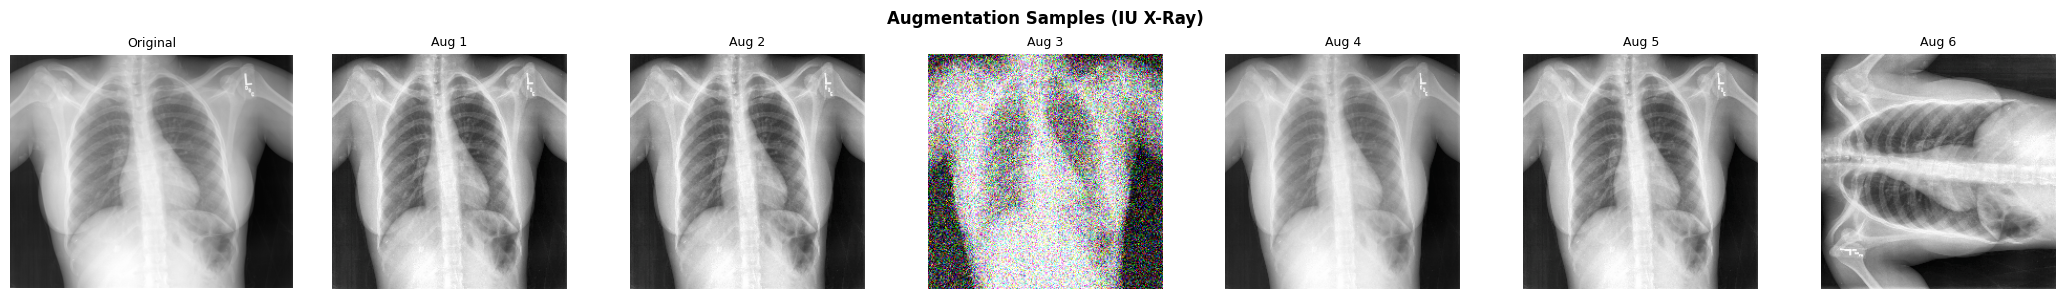

 Augmentation pipeline ready
Training transforms  : 8 steps
Validation transforms: 3 steps


In [23]:
def get_transforms(is_training: bool = True, img_size: int = 224) -> A.Compose:
    """
    IU X-Ray specific augmentation.
    Training: mild augmentation only — X-rays are diagnostically sensitive.
    """
    norm = A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    if is_training:
        return A.Compose([
            A.Resize(img_size, img_size),
            A.HorizontalFlip(p=0.3),
            A.RandomRotate90(p=0.1),
            A.OneOf([
                A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=1),
                A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=1),
                A.RandomGamma(gamma_limit=(90, 110), p=1),
            ], p=0.4),
            A.OneOf([
                A.GaussNoise(var_limit=(5.0, 20.0), p=1),
                A.GaussianBlur(blur_limit=(3, 5), p=1),
            ], p=0.2),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05,
                               rotate_limit=5, p=0.3),
            norm,
            ToTensorV2(),
        ])
    else:
        return A.Compose([A.Resize(img_size, img_size), norm, ToTensorV2()])


def visualize_augmentations(img_path: str, n_aug: int = 6):
    """Show original + augmented versions side-by-side."""
    orig = cv2.imread(img_path)
    if orig is None:
        print("Image not found:", img_path); return
    orig_rgb = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
    transform = get_transforms(is_training=True)

    fig, axes = plt.subplots(1, n_aug + 1, figsize=(3*(n_aug+1), 3))
    axes[0].imshow(orig_rgb); axes[0].set_title("Original", fontsize=9); axes[0].axis('off')
    for i in range(1, n_aug + 1):
        aug  = transform(image=orig_rgb)['image']
        mean = np.array([0.485, 0.456, 0.406]); std = np.array([0.229, 0.224, 0.225])
        disp = (aug.permute(1,2,0).numpy() * std + mean).clip(0, 1)
        axes[i].imshow(disp); axes[i].set_title(f"Aug {i}", fontsize=9); axes[i].axis('off')
    plt.suptitle("Augmentation Samples (IU X-Ray)", fontweight='bold')
    plt.tight_layout(); plt.show()


# Uncomment to visualise:
visualize_augmentations(df['frontal_path'].iloc[0])
print(" Augmentation pipeline ready")
print(f"Training transforms  : {len(get_transforms(True).transforms)} steps")
print(f"Validation transforms: {len(get_transforms(False).transforms)} steps")


## Step 8 — PyTorch Dataset & Optimised DataLoaders

In [24]:
class IUXrayDataset(Dataset):
    """
    Optimised PyTorch Dataset for IU Chest X-Ray.

    Each sample returns:
        frontal_img  (3, 224, 224) tensor
        lateral_img  (3, 224, 224) tensor   ← same as frontal if lateral missing
        findings     str
        impression   str
        uid          int
    """

    def __init__(self, df: pd.DataFrame, transform=None,
                 is_training: bool = True, image_cache: dict = None,
                 skip_validation: bool = True):
        self.df           = df.copy().reset_index(drop=True)
        self.transform    = transform or get_transforms(is_training)
        self.image_cache  = image_cache
        if not skip_validation:
            self._validate()

    def _validate(self):
        # Vectorized — much faster than iterrows()
        mask    = self.df['frontal_path'].apply(lambda p: Path(p).exists())
        removed = (~mask).sum()
        self.df = self.df[mask].reset_index(drop=True)
        if removed:
            logging.warning(f"Removed {removed} rows with missing frontal images")

    def _load_image(self, path: str) -> np.ndarray:
        """Load image, using RAM cache if available."""
        if self.image_cache is not None and path in self.image_cache:
            return self.image_cache[path]
        img = cv2.imread(str(path))
        if img is None:
            return np.zeros((224, 224, 3), dtype=np.uint8)
        return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row     = self.df.iloc[idx]
        frontal = self._load_image(row['frontal_path'])
        lateral = self._load_image(row['lateral_path'])

        frontal_t = self.transform(image=frontal)['image']
        lateral_t = self.transform(image=lateral)['image']

        return {
            'frontal'   : frontal_t,
            'lateral'   : lateral_t,
            'findings'  : str(row.get('findings_clean', '')),
            'impression': str(row.get('impression_clean', '')),
            'uid'       : int(row['uid']),
            'indication': str(row.get('clinical_history', '')), 
        }


def iu_collate_fn(batch):
    return {
        'frontal'   : torch.stack([b['frontal']    for b in batch]),
        'lateral'   : torch.stack([b['lateral']    for b in batch]),
        'findings'  : [b['findings']               for b in batch],
        'impression': [b['impression']              for b in batch],
        'uid'       : [b['uid']                    for b in batch],
        'indication': [b['indication']              for b in batch],
    }


def build_image_cache(df: pd.DataFrame) -> dict:
    """
    Pre-load ALL images into RAM once.
    ~3,900 reports × 2 images × ~150KB ≈ 1.2 GB.
    Skip if RAM is limited.
    """
    all_paths = list(set(df['frontal_path'].tolist() + df['lateral_path'].tolist()))
    cache = {}
    print(f"Pre-caching {len(all_paths)} images to RAM...")
    for path in tqdm(all_paths):
        img = cv2.imread(str(path))
        if img is None:
            cache[path] = np.zeros((224, 224, 3), dtype=np.uint8)
        else:
            cache[path] = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    print(f" Cached {len(cache)} images")
    return cache


def get_dataloaders(df: pd.DataFrame,
                    batch_size: int       = 16,
                    train_split: float    = 0.8,
                    num_workers: int      = 0,       # ← 0 is faster on Windows
                    use_cache: bool       = False,
                    skip_validation: bool = True,
                    seed: int             = 42):
    """
    80 / 10 / 10 train/val/test split.
    use_cache=True       → pre-loads all images into RAM for maximum speed.
    skip_validation=True → skips per-file existence check (fast after first run).
    num_workers=0        → avoids Windows multiprocessing overhead.
    """
    df = df.copy()
    df['wc_bucket'] = pd.qcut(
        df['findings_clean'].str.split().str.len().fillna(0),
        q=5, labels=False, duplicates='drop'
    )

    train_df, temp_df = train_test_split(df, train_size=train_split,
                                          random_state=seed, stratify=df['wc_bucket'])
    val_df,  test_df  = train_test_split(temp_df, train_size=0.5, random_state=seed)

    image_cache = build_image_cache(df) if use_cache else None

    def make_loader(split_df, training):
        dataset = IUXrayDataset(
            split_df,
            is_training=training,
            image_cache=image_cache,
            skip_validation=skip_validation
        )
        return DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=training,
            num_workers=0,            # ← Windows fix: no multiprocessing
            pin_memory=torch.cuda.is_available(),
            collate_fn=iu_collate_fn,
            persistent_workers=False, # ← must be False when num_workers=0
            prefetch_factor=None,     # ← must be None when num_workers=0
            drop_last=training,
        )

    train_loader = make_loader(train_df, True)
    val_loader   = make_loader(val_df,   False)
    test_loader  = make_loader(test_df,  False)

    print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
    print(f"Batches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")
    return train_loader, val_loader, test_loader, train_df, val_df, test_df


# ── Instantiate ──────────────────────────────────────────────────────────────
train_loader, val_loader, test_loader, train_df, val_df, test_df = \
    get_dataloaders(df, batch_size=16, num_workers=0,
                    use_cache=False, skip_validation=True)

# ── Verify one batch ─────────────────────────────────────────────────────────
batch = next(iter(train_loader))
print(f"\nBatch frontal shape  : {batch['frontal'].shape}")
print(f"Batch lateral shape  : {batch['lateral'].shape}")
print(f"Findings sample      : {batch['findings'][0][:100]}…")
print(f"Impression sample    : {batch['impression'][0][:80]}…")

Train: 2669 | Val: 334 | Test: 334
Batches — Train: 166 | Val: 21 | Test: 21

Batch frontal shape  : torch.Size([16, 3, 224, 224])
Batch lateral shape  : torch.Size([16, 3, 224, 224])
Findings sample      : the cardiomediastinal silhouette is within normal limits for appearance. pulmonary hypoinflation wit…
Impression sample    : 1. pulmonary hypoinflation. otherwise, no acute intrathoracic abnormality.…


## Step 9 — Word Cloud & Vocabulary Statistics

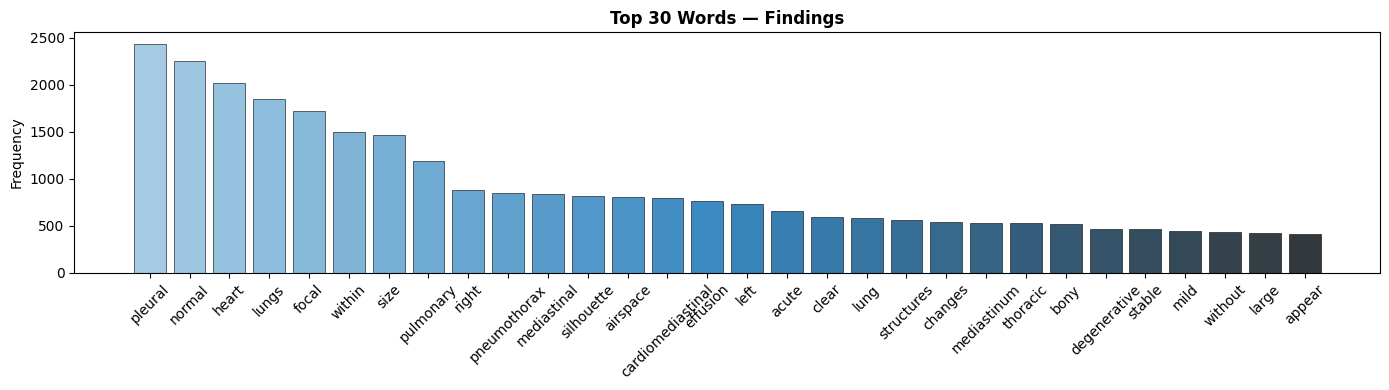

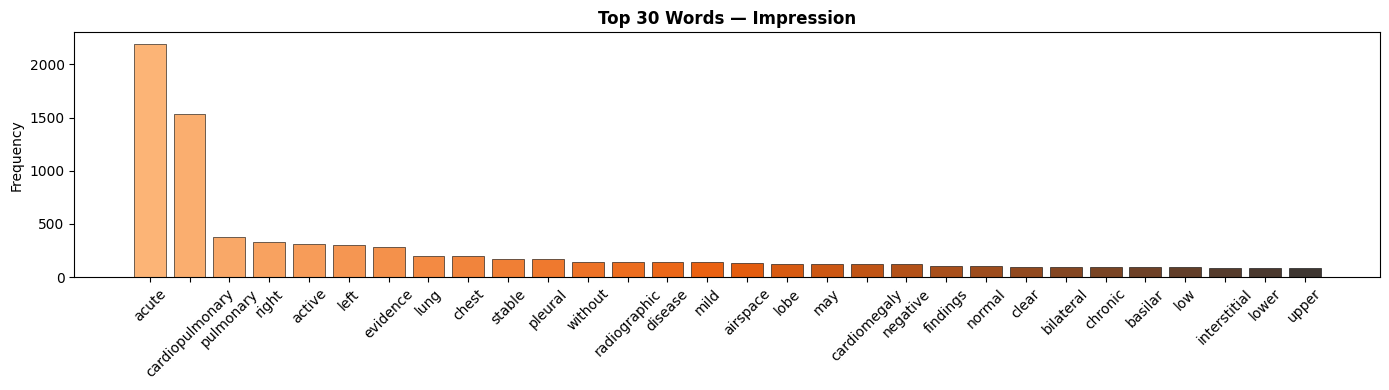


Vocabulary size: 1589 unique words
Total findings tokens  : 49,770
Total impression tokens: 13,959


In [25]:
def plot_top_words(texts, title, top_n=30, color='Blues_d'):
    all_words = []
    for t in texts:
        words = [w for w in str(t).lower().split()
                 if w not in STOP_WORDS and len(w) > 2 and w.isalpha()]
        all_words.extend(words)
    top  = Counter(all_words).most_common(top_n)
    words_list, counts = zip(*top)

    fig, ax = plt.subplots(figsize=(14, 4))
    palette = sns.color_palette(color, n_colors=top_n)
    ax.bar(words_list, counts, color=palette, edgecolor='black', linewidth=0.4)
    ax.set_title(f"Top {top_n} Words — {title}", fontsize=12, fontweight='bold')
    ax.set_ylabel("Frequency"); ax.tick_params(axis='x', rotation=45)
    plt.tight_layout(); plt.show()
    return Counter(all_words)


findings_vocab   = plot_top_words(df['findings_clean'],   "Findings",   color='Blues_d')
impression_vocab = plot_top_words(df['impression_clean'], "Impression", color='Oranges_d')

total_vocab = len(set(list(findings_vocab.keys()) + list(impression_vocab.keys())))
print(f"\nVocabulary size: {total_vocab} unique words")
print(f"Total findings tokens  : {sum(findings_vocab.values()):,}")
print(f"Total impression tokens: {sum(impression_vocab.values()):,}")


## Step 10 — Save Preprocessed CSV

In [26]:
# Save for use in Notebook 2
df.to_csv("preprocessed_df.csv", index=False)
print(f" Saved preprocessed_df.csv  ({len(df)} rows, {len(df.columns)} columns)")
print("Columns:", df.columns.tolist())


 Saved preprocessed_df.csv  (3337 rows, 13 columns)
Columns: ['uid', 'frontal_path', 'lateral_path', 'mesh_tags', 'problems', 'image', 'indication', 'comparison', 'findings', 'impression', 'findings_clean', 'impression_clean', 'clinical_history']
